### Building A Citation Network Using SuperNeuroMAT

A great reference point for the capabilities of a neural network is its ability to accurately predict results within a citation network. A citation network is a collection of papers across various specified topics, along with what papers they cited and/or were cited by. Given a new paper and its citations, the network must determine which topic the paper should be categorized into. This problem is a more complex problem that we can model within SuperNeuroMAT.

One of the main datasets used for citation network creation is the citeseer dataset, containing 3312 publications across 6 categories with 4732 citations, including a limited dictionary of 3703 words, their presence or lack thereof represented by 0's and 1's. For this program, we will be utilizing the microseer dataset, a scaled down version created by ORNL with only 84 publications, still including their data from the dictionary of 3703 words. The 6 categories are IR, DB, Agents, HCI, ML, and AI papers.

In [7]:
#first, let's load up the necessary libraries for the network
import superneuromat as snm
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

#then, we will create our spiking neural network in SuperNeuroMAT
cit=snm.SNN()

#for future training, we will set the STDP values for apos and aneg for the system
cit.stdp=True
cit.apos=[0.075]
cit.aneg=[-0.0005]

Now that we have the base network set up, we need to transform our dataset into something we can use for our synapses and spike train. Look over the data within the tutorials folder and observe its features before you continue.

In [8]:
d=[]

#breaks down the file into its individual lines
with open("11_1_microseer_data.content", "r") as file:
    c = [line.strip() for line in file]

#breaks each line into a list of each separate value or string
for i in c:
    d.extend(i.split())


#ensures all number values are integers
for i in range(len(d)):
    if i%3705 !=0 and (i+1)%3705 !=0:
        d[i]=int(d[i])

#breaks all the items of the list into strings corresponding to each of the 84 training datapoints
data = [d[i : i + 3705] for i in range(0, len(d), 3705)]


#now that we have parsed through the data, we want to prepare it for training
#we are going to break into general x (all the 0/1 datapoints) and y (one of 6 categories)
x=[]
y=[]
for i in data:
    xidx=[]
    for j in range (len(i)):
        if j==3704:
           y.append(i[j])
        elif j!=0:
            xidx.append(i[j])
    x.append(xidx)

#we are using 86% training and 14% testing or 72 samples training and 12 samples testing.
xtrain,xtest,ytrain,ytest = train_test_split(x,y, test_size=0.14,random_state=21)


Now that we have our data organized, we can go about the creation of the network. We will have 6 output neurons, one for each paper category, and 3703 input neurons, one for each 0/1 value from our selective dictionary, labeled as papers.

In [9]:
categories=[]
for i in range (6):
    #these neurons will have large thresholds for now so that they will not spike without user input
    id=cit.create_neuron(threshold=10000)
    categories.append(id)
#IR, DB, Agents, HCI, ML, AI

papers=[]
for i in range (3703):
    neuron=cit.create_neuron(threshold=0)
    papers.append(neuron.idx)

Next, we will create some helpful functions that will aid us down the road. These two functions will take a specific sample and categorize it by the string (topic) in its ytrain. We will take a slightly different approach for the testing data.

In [10]:
#for our training data: given an index, returns the neuron of the category
def find_categories(i):
    if ytrain[i]=='IR':
        a=categories[0]
    if ytrain[i]=='DB':
        a=categories[1]
    if ytrain[i]=='Agents':
        a=categories[2]
    if ytrain[i]=='HCI':
        a=categories[3]
    if ytrain[i]=='ML':
        a=categories[4]
    if ytrain[i]=='AI':
        a=categories[5]
    return(a)

#for our testing data: given an index, returns a numerical index value
def find_categories_test(i):
    if ytest[i]=='IR':
        a=0
    if ytest[i]=='DB':
        a=1
    if ytest[i]=='Agents':
        a=2
    if ytest[i]=='HCI':
        a=3
    if ytest[i]=='ML':
        a=4
    if ytest[i]=='AI':
        a=5
    return(a)

Now we get to the more complex aspect of this problem. For each item in xtrain, we want to create synapses between each 1 within the dictionary and the corresponding topic for the specific item we are analyzing. We will add these to a list to keep track of them better, and their indices in the system will correspond to their list placement.

In [11]:
synapse_categories = [[],[],[],[],[],[]]

for f in range(6):
    #for each category
    for i in range(len(xtrain)):
        #checks every xtrain item to determine which fit the category
        for j in range(3703):
            #each "word" within the item
            if xtrain[i][j]!=0:
                #if this word is a 1
                b=len(cit.synaptic_weights)
                a=find_categories(i)
                #creates a new synapse for each unique connection, adds them to their proper place in the synapse category list
                if a.idx==f:   
                    syn=cit.create_synapse(papers[j],a,weight=0,stdp_enabled=True,exist='dontadd')
                    if len(cit.synaptic_weights)!=b:
                        synapse_categories[a.idx].append(syn)
    #repeat the process for each category
    f+=1

For the final part of the training step, we need to add spikes and simulate the program. We will add input spikes (to the papers neurons) at intervals of two time steps, alternating with large spikes to the category neurons. When these neurons spike within a time step of each other, the STDP will be activated, training the neural network. You can look at the spike train and see the process in action.

In [12]:
time_step=0

for i in range(len(xtrain)):
    #for each xtrain item, determine what topic it is
    a=find_categories(i)
    for j in range(3703):
        if xtrain[i][j]!=0:
            #if it is a 1, add a spike at the current time step to the given paper
            cit.add_spike(time_step,papers[j],1)
    #move forward for the output spike and add it at new time step
    time_step+=1
    cit.add_spike(time_step,a,100000)
    #move forward and repeat the process
    time_step+=1


#this is enough time to go through all input and output spikes for xtrain's 72 entries

cit.simulate(150)
#cit.pretty_print(150)
#print(cit.synaptic weights)

At this point, our neural network is officially trained. You can check the synaptic weights of the system to see what the STDP has achieved: the more associated a set of words is to a topic, the larger the weights will be. Now we will see how effective our training was, starting with making a copy of our network so we will not corrupt our training.

In [13]:
#create a copy of the network without STDP synapse adjustment
cit_copy= cit.copy()
cit_copy.reset()
cit_copy.stdp_enabled = False

#return it to time step zero so we can easily view the data
time_step=0

#we are going to set all of the thresholds to a fixed value
#play around with this threshold to see how the spike train later changes
for j in categories:
    cit_copy.neuron_thresholds[j.idx]=4.5

We will now add spikes for all of our 0/1 values in the xtest set every other time step, and we can now let the training do its job. Observe how the spike patterns on the first 6 neuron ids represent the snn's determination of the topic

In [14]:
for i in range(len(xtest)):
    for j in range(3703):
        if xtest[i][j]!=0:
            cit_copy.add_spike(time_step,papers[j],1)
    time_step+=2

cit_copy.simulate(30)
cit_copy.pretty_print(30)

SNN with 3709 neurons and 1709 synapses @ 0x1fea62da120
STDP is globally enabled over 1 time steps.
apos: [0.075]
aneg: [-0.0005]
1709 synapses have STDP enabled.

Neuron Info (3709):
   idx       state      thresh        leak  ref_state  ref_period spikes
     0           0         4.5         inf          0           0 [----⋯------]
     1           0         4.5         inf          0           0 [----⋯------]
     2           0         4.5         inf          0           0 [----⋯------]
     3           0         4.5         inf          0           0 [----⋯------]
     4           0         4.5         inf          0           0 [----⋯------]
     5           0         4.5         inf          0           0 [----⋯------]
     6           0           0         inf          0           0 [----⋯------]
     7           0           0         inf          0           0 [----⋯------]
     8           0           0         inf          0           0 [----⋯------]
     9           0     

Now, we will determine how accurate our system is. For every entry in the xtrain, we will consier the sum of the weights for the synapses connecting the "words" in the train to each category, then determine which of these sums are greatest. We will do a small calculation by dividing the sums by the total number of synapses that each topic contains, normalizing the data.

In [15]:
#just some setup for the visualization of the confusion matrix
confusion=np.zeros((6,6), dtype=int)

#sets lists for our accuracy determinations
predictions=[]
all_confidences=[]
is_correct=[]
total=0
correct=0


a=len(synapse_categories[0])
b=len(synapse_categories[1])
c=len(synapse_categories[2])
d=len(synapse_categories[3])
e=len(synapse_categories[4])

#allows us to index synapses easily
synapse_lengths = [0,a,a+b,a+b+c,a+b+c+d,a+b+c+d+e]


In [16]:
#now for the interesting part

#for each testing data entry
for k in range(len(xtest)):
    #establish running count of activation values
    activations = []

    #for each category
    for i in range(len(categories)):
        #checks the category of this entry to xtest
        a=synapse_categories[i]
        activation_sum=0

        #for every synapse for this category
        for j in range(len(a)):
            #determines which synapse it is in the system
            idx= synapse_lengths[i] + j

            #finds the weight of this individual synapse
            weight = cit_copy.synaptic_weights[idx]
            z=cit_copy.pre_synaptic_neuron_ids[idx]-6
            if xtest[k][z] != 0:
                #for the nonzero entries, add the weights to our running count
                activation_sum += weight*300/len(a) 

        #adds the running count to a list for each category
        activations.append(activation_sum) 

    #finds which activation is higher and labels that the prediction
    max_activation = max(activations)
    prediction = activations.index(max_activation)
    predictions.append(prediction)

    #adds the determined prediction and the actual topic to the confusion matrix
    confusion[find_categories_test(k), prediction] +=1

    #gives us the number of correct and the total for accuracy
    total+=1
    if prediction==find_categories_test(k):
        correct+=1
        is_correct.append(True)
    else:
        is_correct.append(False)

    #allows us to see the margin of confidence for both correct and incorrect entries
    a = activations.pop(activations.index(max_activation))
    b = max(activations)
    confidence = a - b
    all_confidences.append(confidence)

Now that we have collected all of this information, we can draw some conclusions. We will find out how many of the predictions our model made are correct and represent that with an accuracy % and represent its confidence for correct and incorrect predictions. These two points will give us a good diagnostic of where our model is.

0.9166666666666666
correct average confidence: 0.7547747414724291

incorrect average confidence: 0.5076778154478565


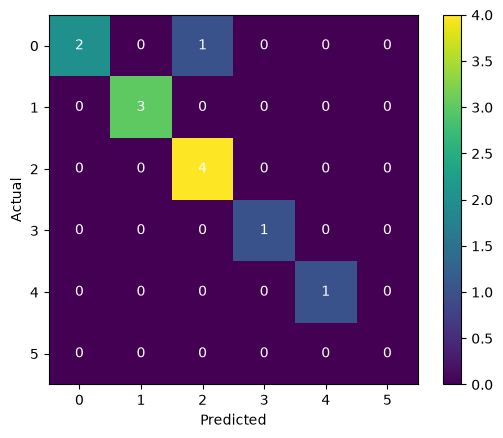

In [17]:
#create lists for both types of confidences
correct_confidences=[]
incorrect_confidences=[]

for i in range(len(is_correct)):
    #add all correct predictions' confidences to the correct confidence list
    if is_correct[i]==True:
        correct_confidences.append(all_confidences[i])

    #add all others to the incorrect confidence list
    else:
        incorrect_confidences.append(all_confidences[i])

#average both of these
correct_avg_confidence = np.sum(correct_confidences) / len(correct_confidences)
incorrect_avg_confidence = np.sum(incorrect_confidences) / len(incorrect_confidences)    
    
#determine accuracy based on correct predictions out of total predictions
accuracy = correct/total
print(accuracy)
print("correct average confidence:", correct_avg_confidence)
print()
print("incorrect average confidence:", incorrect_avg_confidence)

#print confusion matrix
plt.imshow(confusion)
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(range(6))
plt.yticks(range(6))

for i in range(6):
    for j in range(6):
        plt.text(j, i, confusion[i, j],
                 ha="center", va="center",
                 color="white")

plt.show()

Congratulations on your completion of this tutorial! You can test a variety of different random states and see how the accuracy fluctuates. You can also see how neuron thresholds, apos and aneg values, or further comprehension methods to see how they influence the results.